**Imports**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

**Code**

Here we made a variable called "df" inside of it we put the .csv

In [2]:
df = pd.read_csv("cleaned_data.csv")

Here we use one-hot encoding on two *categorical* columns, which are : Heating and Central Air. Then putting our outputs into either one of two prefixes depending on where the data came from, and the two prefixes are : Heat and C-Air.

In [3]:
oneHotEncoding = pd.get_dummies(df, columns = ["Heating", "Central Air"], prefix = ["Heat", "C-Air"])
print(oneHotEncoding.head())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Sale Condition SalePrice Heat_Floor  \
0   NaN       IR1          Lvl  ...         Normal  215000.0      False   
1   NaN       Reg          Lvl  ...         Normal  105000.0      False   
2   NaN       IR1          Lvl  ...         Normal  172000.0      False   
3   NaN       Reg          Lvl  ...         Normal  244000.0      False   
4   NaN       IR1          Lvl  ...         Normal  189900.0      False   

  Heat_GasA Heat_GasW Heat_Grav Heat_OthW Heat_Wall  C-Air_N  C-Air_Y  
0      True   

Here we use ordinal encoding to encode every piece of data in the column "Kitchen Qual" into three categories and they are : "low", "medium" and "high" (From course slides)

In [4]:
quality_map = {"Po" : "low",
               "Fa" : "low",
               "TA" : "medium",
               "Gd" : "high",
               "Ex" : "high"} # From ChatGPT, I couldn't fix a problem which was when I ONLY use ordinal encoding everything sets to "-1"

ordinal_enc = pd.CategoricalDtype(categories = ["low", "medium", "high"], ordered = True)

df["Kitchen Qual Level"] = df["Kitchen Qual"].map(quality_map)
df["Kitchen Qual Ordinal"] = df["Kitchen Qual Level"].astype(ordinal_enc).cat.codes

print(df["Kitchen Qual Ordinal"])

0       1
1       1
2       2
3       2
4       1
       ..
2925    1
2926    1
2927    1
2928    1
2929    1
Name: Kitchen Qual Ordinal, Length: 2930, dtype: int8


Here we are using Standard Scaler to scale two columns and they are : "Total Bsmt SF" and "1st Flr SF". There are two outputs and they are for mean and std (Standard Devation) (From course slides)

In [5]:
std_scaler = StandardScaler()
df[["BSMT_std", "FLR_std"]] = std_scaler.fit_transform(df[["Total Bsmt SF", "1st Flr SF"]])
print(df[["BSMT_std", "FLR_std"]].agg(["mean", "std"]))

          BSMT_std       FLR_std
mean  2.522924e-16  1.818795e-17
std   1.000171e+00  1.000171e+00


Here we made 2 different *Domain Driven* features, one of them is *"price_per_sqft"* which was taken from the instruction for this phase and tells you how much every square foot of this house costs, then we have the next feature which is *"overall score"* which was taken from Google Gemini and it tells you the overall score of the house out of 100 by multiplying the condition and the quality of the house (Note : This feature's **idea** was only taken from Google Gemini, the code was written by me) (I have looked and read the course slides to remember how to do it correctly)

In [6]:
df["price_per_sqft"] = np.where(df["Gr Liv Area"] > 0, df["SalePrice"] / df["Gr Liv Area"], 0)
df["overall_score"] = df["Overall Qual"] * df["Overall Cond"]

print(df[["SalePrice", "Gr Liv Area", "price_per_sqft"]].head())
print("\n")
print(df[["Overall Qual", "Overall Cond", "overall_score"]].head())

   SalePrice  Gr Liv Area  price_per_sqft
0   215000.0         1656      129.830918
1   105000.0          896      117.187500
2   172000.0         1329      129.420617
3   244000.0         2110      115.639810
4   189900.0         1629      116.574586


   Overall Qual  Overall Cond  overall_score
0             6             5             30
1             5             6             30
2             6             6             36
3             7             5             35
4             5             5             25


Here we made an interaction feature, where we add two different features and the features are : "Bedroom AbvGr" (A ready feature in the dataset) and "Total Bath" (A feature we just made in this cell) to make the interaction feature which is Bath_Per_Bedroom, this new feature gives us the bath to bedroom ratio

In [7]:
df["Total Bath"] = (df["Full Bath"] + (0.5 * df["Half Bath"]) + df["Bsmt Full Bath"].fillna(0) + (0.5 * df["Bsmt Half Bath"]).fillna(0))
df["Bath_Per_Bedroom"] = df["Total Bath"] / df["Bedroom AbvGr"]
print(df[["Total Bath", "Bedroom AbvGr", "Bath_Per_Bedroom"]])

      Total Bath  Bedroom AbvGr  Bath_Per_Bedroom
0            2.0              3          0.666667
1            1.0              2          0.500000
2            1.5              3          0.500000
3            3.5              3          1.166667
4            2.5              3          0.833333
...          ...            ...               ...
2925         2.0              3          0.666667
2926         2.0              2          1.000000
2927         1.5              3          0.500000
2928         2.0              2          1.000000
2929         2.5              3          0.833333

[2930 rows x 3 columns]


Here we fixed a right skewed column (as shown in the first picture) into a normally distributed one (as seen in the second picture) using np.log1p()

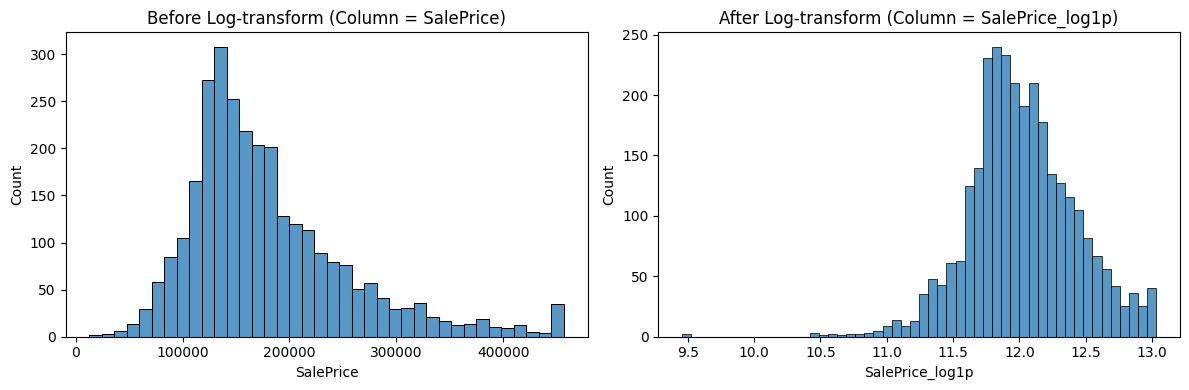

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], ax=axes[0])
axes[0].set_title("Before Log-transform (Column = SalePrice)")

df["SalePrice_log1p"] = np.log1p(df["SalePrice"])
sns.histplot(df["SalePrice_log1p"], ax=axes[1])
axes[1].set_title("After Log-transform (Column = SalePrice_log1p)")

plt.tight_layout()
plt.show()

Here we used binning which is when we kindof categorize the specific **numeric** column that we picked using python, which is here the *"Year Built"* column into more than one label and having it have a from -> to date, the *"Old"* label is from *1872 -> 1960*, the *"Recent"* label is from *1960 -> 1995*, the *"New"* label is from *1995 -> 2010*

In [9]:
edges = [1872, 1960, 1995, 2010]
labels = ["Old", "Recent", "New"]
df["Year Built Groups"] = pd.cut(df["Year Built"], bins = edges, labels = labels, right = False)
df["Year Built Groups"].head()

0    Recent
1    Recent
2       Old
3    Recent
4       New
Name: Year Built Groups, dtype: category
Categories (3, object): ['Old' < 'Recent' < 'New']

Here we dropped the most redunent *Natrual* (a feature that we didn't create) which was *"Order"*. The *"Order"* feature was 0.975 correlated with the feature *"Yr Sold"*

In [10]:
corr_matrix = df[["Order", "Yr Sold"]].corr()
print(corr_matrix["Yr Sold"])
df1 = df.copy()
df1.drop("Order", axis = 1, inplace = True)
df1.head()

Order     -0.975993
Yr Sold    1.000000
Name: Yr Sold, dtype: float64


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Kitchen Qual Level,Kitchen Qual Ordinal,BSMT_std,FLR_std,price_per_sqft,overall_score,Total Bath,Bath_Per_Bedroom,SalePrice_log1p,Year Built Groups
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,medium,1,0.064433,1.267003,129.830918,30,2.0,0.666667,12.278398,Recent
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,medium,1,-0.385015,-0.672643,117.187500,30,1.0,0.500000,11.561725,Recent
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,high,2,0.629649,0.432445,129.420617,36,1.5,0.500000,12.055256,Old
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,high,2,2.402474,2.425687,115.639810,35,3.5,1.166667,12.404928,Recent
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,medium,1,-0.280598,-0.590974,116.574586,25,2.5,0.833333,12.154258,New


This is code from Google Gemini to find the most correlated pairs (to help us for the last task instead of doing it manually)

In [11]:
# Get the correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr().abs()

# Filter out the diagonal (1.0) and find the highest pairs
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

# Look at the top 5
print("Your actual top correlated pairs:")
print(sol.head(5))

Your actual top correlated pairs:
1st Flr SF     FLR_std            1.000000
Total Bsmt SF  BSMT_std           1.000000
Order          Yr Sold            0.975993
SalePrice      SalePrice_log1p    0.955039
Garage Cars    Garage Area        0.889676
dtype: float64
